In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score
)

from sklearn.preprocessing import label_binarize


In [2]:
df = pd.read_csv("dataset_limpio.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.62212,1.0,0.000647,0.000633,0.039879,electron,22109111
1,1.314830,0.945947,-3.09573,1.0,0.000698,0.000623,-0.029173,track,22109111
2,1.384250,-1.488470,-2.93427,1.0,0.000703,0.000611,-0.029091,track,22109111
3,0.973126,0.576321,-2.91378,1.0,0.000704,0.000611,-0.020457,track,22109111
4,1.697150,1.373240,-2.92621,1.0,0.000701,0.000623,-0.020329,track,22109111


In [3]:
# Variables
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificador
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado (opcional pero consistente con el Notebook anterior)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
%%time
model_dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model_dt.fit(X_train_scaled, y_train)


CPU times: user 529 ms, sys: 6.17 ms, total: 535 ms
Wall time: 570 ms


DecisionTreeClassifier(random_state=42)

=== Reporte de clasificación (Decision Tree) ===
              precision    recall  f1-score   support

    electron       0.03      0.03      0.03        37
        muon       0.01      0.02      0.01        99
      photon       1.00      1.00      1.00        63
       track       0.98      0.97      0.98      7528

    accuracy                           0.96      7727
   macro avg       0.50      0.50      0.50      7727
weighted avg       0.97      0.96      0.96      7727



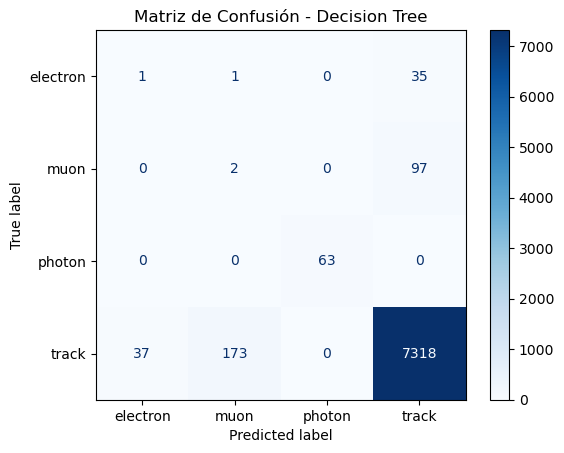

In [5]:
y_pred_dt = model_dt.predict(X_test_scaled)

print("=== Reporte de clasificación (Decision Tree) ===")
print(classification_report(y_test, y_pred_dt, target_names=classes))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Decision Tree")
plt.show()


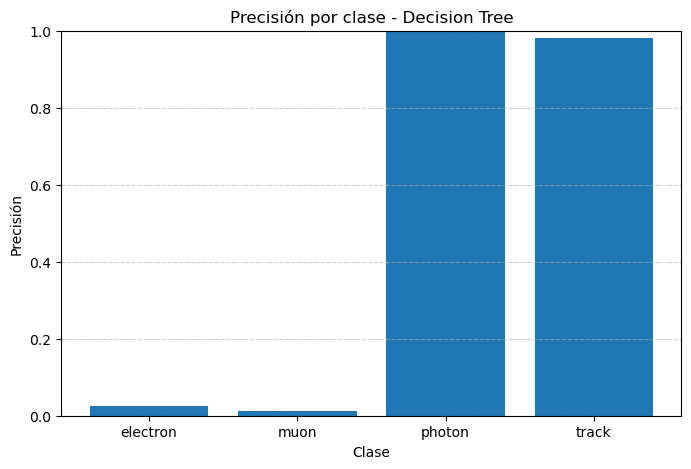

In [6]:
precisiones_dt = precision_score(y_test, y_pred_dt, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_dt)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - Decision Tree")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

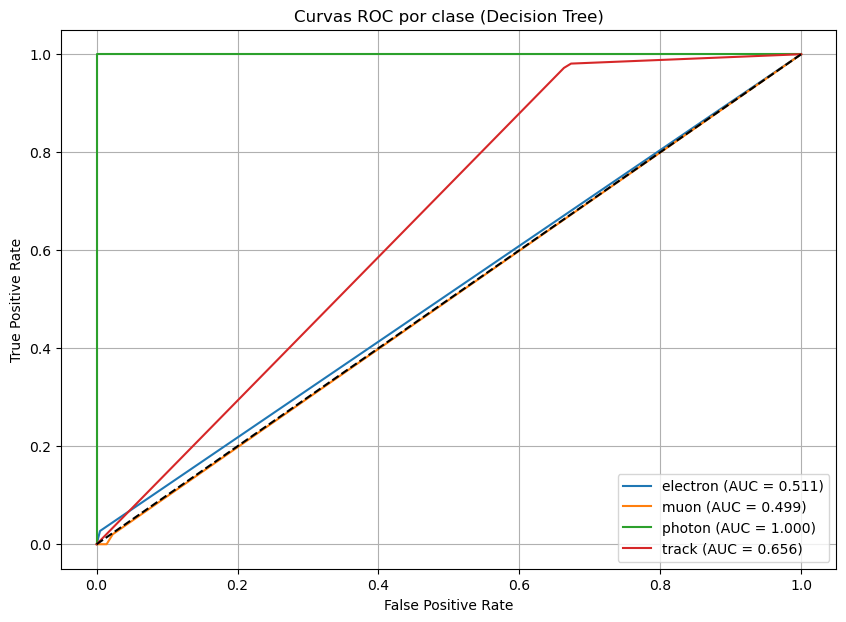

In [7]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_dt = model_dt.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase (Decision Tree)")
plt.legend()
plt.grid(True)
plt.show()


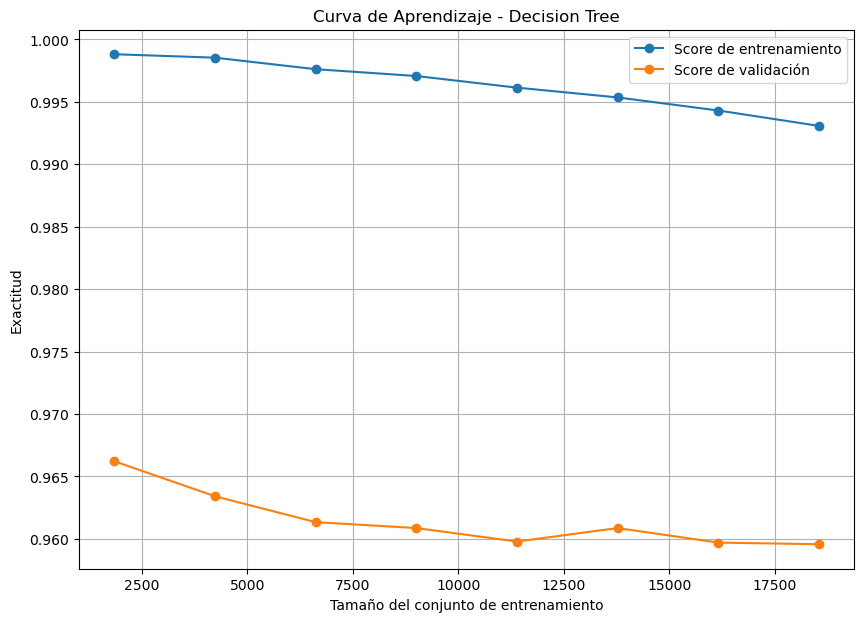

In [8]:
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()


## SIN TRACKS

In [9]:
df = pd.read_csv("dataset_limpio_notracks.csv")
df.head()

,pt,eta,phi,charge,pos_x,pos_y,pos_z,particle_type,event_id
0,2.400150,0.739663,1.622120,1.0,0.000647,0.000633,0.039879,electron,22109111
1,0.838852,-1.914380,2.947160,-1.0,0.000671,0.000501,-0.012415,muon,22109111
2,2.646500,-2.273300,0.817141,1.0,0.000773,0.000570,0.002240,muon,22109111
3,1.736600,-2.463090,-1.792570,1.0,0.002726,0.000183,-0.001184,muon,22109111
4,35.556000,0.005784,1.834000,0.0,0.000726,0.000609,-0.047592,photon,652620608


In [10]:
# Variables
X = df[["pt", "eta", "phi", "charge", "pos_x", "pos_y", "pos_z"]]
y = df["particle_type"]

# Codificador
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
classes = encoder.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

# Escalado (opcional pero consistente con el Notebook anterior)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
%%time
model_dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model_dt.fit(X_train_scaled, y_train)

CPU times: user 7.53 ms, sys: 4.5 ms, total: 12 ms
Wall time: 13.1 ms


DecisionTreeClassifier(random_state=42)

=== Reporte de clasificación (Decision Tree) ===
              precision    recall  f1-score   support

    electron       0.52      0.38      0.44        37
        muon       0.79      0.87      0.83        99
      photon       1.00      1.00      1.00        63

    accuracy                           0.82       199
   macro avg       0.77      0.75      0.75       199
weighted avg       0.81      0.82      0.81       199



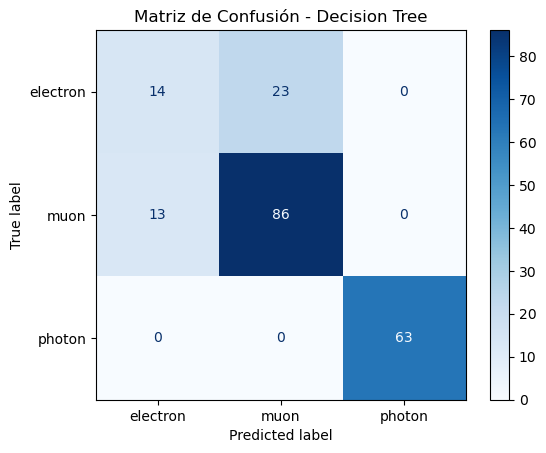

In [12]:
y_pred_dt = model_dt.predict(X_test_scaled)

print("=== Reporte de clasificación (Decision Tree) ===")
print(classification_report(y_test, y_pred_dt, target_names=classes))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Decision Tree")
plt.show()


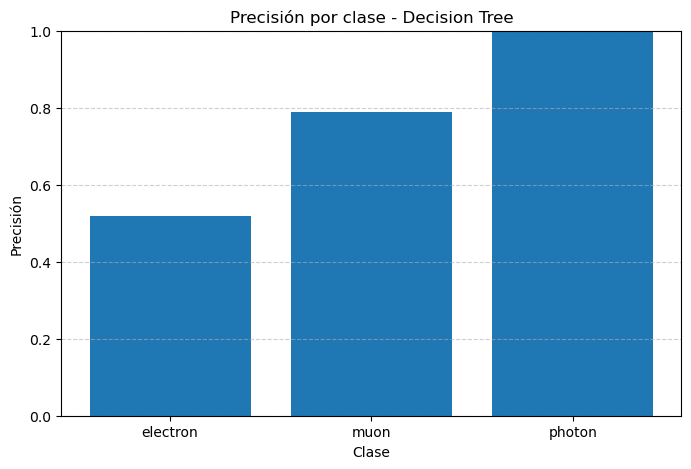

In [13]:
precisiones_dt = precision_score(y_test, y_pred_dt, average=None)

plt.figure(figsize=(8,5))
plt.bar(classes, precisiones_dt)
plt.ylabel("Precisión")
plt.xlabel("Clase")
plt.title("Precisión por clase - Decision Tree")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

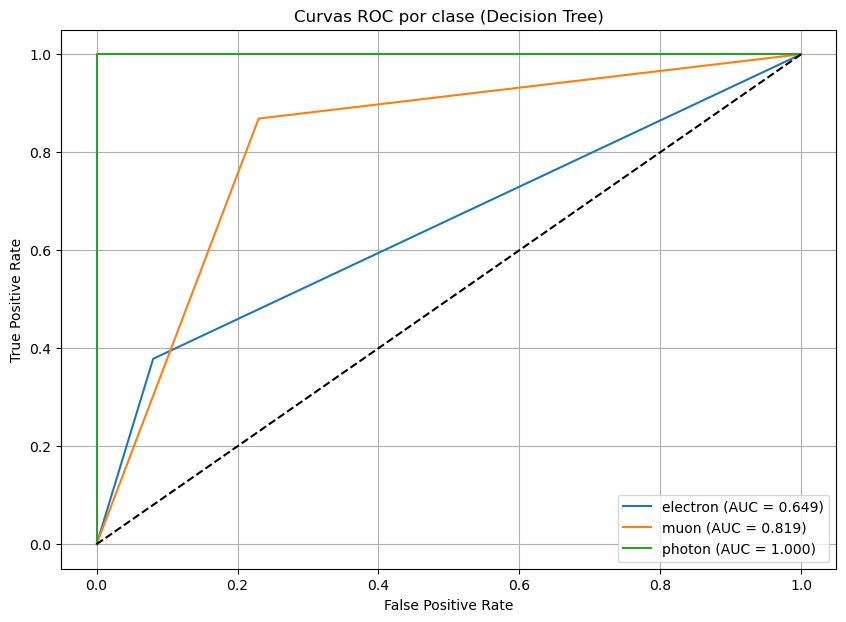

In [14]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

y_scores_dt = model_dt.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 7))

for i, clase in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase (Decision Tree)")
plt.legend()
plt.grid(True)
plt.show()


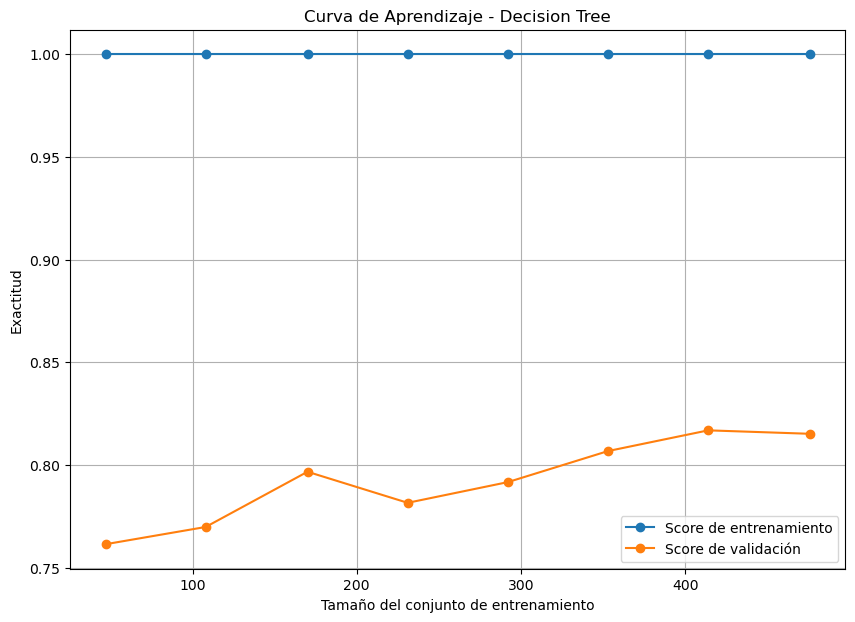

In [15]:
train_sizes, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, marker="o", label="Score de entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Score de validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de Aprendizaje - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()
